In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)

# ── Load clean datasets ──────────────────────────────────────
print('Loading clean datasets...')
print('=' * 55)

pop_malaysia    = pd.read_csv('../data/clean/population_malaysia.csv',    parse_dates=['date'])
pop_state       = pd.read_csv('../data/clean/population_state.csv',       parse_dates=['date'])
pop_district    = pd.read_csv('../data/clean/population_district.csv',    parse_dates=['date'])  # ← ADD THIS
fertility       = pd.read_csv('../data/clean/fertility.csv',              parse_dates=['date'])
fertility_state = pd.read_csv('../data/clean/fertility_state.csv',        parse_dates=['date'])
births          = pd.read_csv('../data/clean/births_annual.csv',          parse_dates=['date'])
deaths          = pd.read_csv('../data/clean/deaths.csv',                 parse_dates=['date'])
marriages       = pd.read_csv('../data/clean/marriages.csv',              parse_dates=['date'])
hh_profile      = pd.read_csv('../data/clean/hh_profile.csv',            parse_dates=['date'])
hh_income           = pd.read_csv('../data/clean/hh_income.csv',              parse_dates=['date'])
hh_income_state     = pd.read_csv('../data/clean/hh_income_state.csv',        parse_dates=['date'])
cpi_headline        = pd.read_csv('../data/clean/cpi_headline.csv',           parse_dates=['date'])
cpi_inflation       = pd.read_csv('../data/clean/cpi_headline_inflation.csv', parse_dates=['date'])
hh_inequality       = pd.read_csv('../data/clean/hh_inequality.csv',          parse_dates=['date'])
hh_inequality_state = pd.read_csv('../data/clean/hh_inequality_state.csv',    parse_dates=['date'])
hh_poverty          = pd.read_csv('../data/clean/hh_poverty.csv',             parse_dates=['date'])
hh_poverty_state    = pd.read_csv('../data/clean/hh_poverty_state.csv',       parse_dates=['date'])
hies_state          = pd.read_csv('../data/clean/hies_state.csv',             parse_dates=['date'])
cpi_lowincome       = pd.read_csv('../data/clean/cpi_lowincome.csv',          parse_dates=['date'])  # ← ADD THIS
cpi_annual          = pd.read_csv('../data/clean/cpi_annual.csv',             parse_dates=['date'])

all_dfs = [
    pop_malaysia, pop_state, pop_district, fertility, fertility_state,
    births, deaths, marriages, hh_profile, hh_income, hh_income_state,
    cpi_headline, cpi_inflation, hh_inequality, hh_inequality_state,
    hh_poverty, hh_poverty_state, hies_state, cpi_lowincome, cpi_annual
]
for df in all_dfs:
    if 'year' not in df.columns:
        df['year'] = df['date'].dt.year

print('✅ All datasets loaded!')
print(f'   pop_malaysia  : {pop_malaysia.shape[0]} rows, years {pop_malaysia["year"].min()}–{pop_malaysia["year"].max()}')
print(f'   hh_income     : {hh_income.shape[0]} rows, years {hh_income["year"].min()}–{hh_income["year"].max()}')

Loading clean datasets...
✅ All datasets loaded!
   pop_malaysia  : 1000 rows, years 1970–1981
   hh_income     : 21 rows, years 1970–2022


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)

print('Loading clean datasets...')
print('=' * 55)

pop_malaysia    = pd.read_csv('../data/clean/population_malaysia.csv',    parse_dates=['date'])
pop_state       = pd.read_csv('../data/clean/population_state.csv',       parse_dates=['date'])
pop_district    = pd.read_csv('../data/clean/population_district.csv',    parse_dates=['date'])
fertility       = pd.read_csv('../data/clean/fertility.csv',              parse_dates=['date'])
fertility_state = pd.read_csv('../data/clean/fertility_state.csv',        parse_dates=['date'])
births          = pd.read_csv('../data/clean/births_annual.csv',          parse_dates=['date'])
deaths          = pd.read_csv('../data/clean/deaths.csv',                 parse_dates=['date'])
marriages       = pd.read_csv('../data/clean/marriages.csv',              parse_dates=['date'])
hh_profile      = pd.read_csv('../data/clean/hh_profile.csv',            parse_dates=['date'])
hh_income           = pd.read_csv('../data/clean/hh_income.csv',              parse_dates=['date'])
hh_income_state     = pd.read_csv('../data/clean/hh_income_state.csv',        parse_dates=['date'])
cpi_headline        = pd.read_csv('../data/clean/cpi_headline.csv',           parse_dates=['date'])
cpi_inflation       = pd.read_csv('../data/clean/cpi_headline_inflation.csv', parse_dates=['date'])
hh_inequality       = pd.read_csv('../data/clean/hh_inequality.csv',          parse_dates=['date'])
hh_inequality_state = pd.read_csv('../data/clean/hh_inequality_state.csv',    parse_dates=['date'])
hh_poverty          = pd.read_csv('../data/clean/hh_poverty.csv',             parse_dates=['date'])
hh_poverty_state    = pd.read_csv('../data/clean/hh_poverty_state.csv',       parse_dates=['date'])
hies_state          = pd.read_csv('../data/clean/hies_state.csv',             parse_dates=['date'])
cpi_lowincome       = pd.read_csv('../data/clean/cpi_lowincome.csv',          parse_dates=['date'])
cpi_annual          = pd.read_csv('../data/clean/cpi_annual.csv',             parse_dates=['date'])

all_dfs = [
    pop_malaysia, pop_state, pop_district, fertility, fertility_state,
    births, deaths, marriages, hh_profile, hh_income, hh_income_state,
    cpi_headline, cpi_inflation, hh_inequality, hh_inequality_state,
    hh_poverty, hh_poverty_state, hies_state, cpi_lowincome, cpi_annual
]
for df in all_dfs:
    if 'year' not in df.columns:
        df['year'] = df['date'].dt.year

pop_max_year = pop_malaysia['year'].max()
pop_row_count = len(pop_malaysia)

print(f'  pop_malaysia    : {pop_row_count:,} rows | years {pop_malaysia["year"].min()} - {pop_max_year}')
print(f'  pop_state       : {len(pop_state):,} rows | years {pop_state["year"].min()} - {pop_state["year"].max()}')
print(f'  fertility       : {len(fertility):,} rows | years {fertility["year"].min()} - {fertility["year"].max()}')
print(f'  fertility_state : {len(fertility_state):,} rows | years {fertility_state["year"].min()} - {fertility_state["year"].max()}')
print(f'  births          : {len(births):,} rows | years {births["year"].min()} - {births["year"].max()}')
print(f'  deaths          : {len(deaths):,} rows | years {deaths["year"].min()} - {deaths["year"].max()}')
print(f'  marriages       : {len(marriages):,} rows | years {marriages["year"].min()} - {marriages["year"].max()}')
print(f'  hh_income       : {len(hh_income):,} rows | years {hh_income["year"].min()} - {hh_income["year"].max()}')
print(f'  cpi_inflation   : {len(cpi_inflation):,} rows | years {cpi_inflation["year"].min()} - {cpi_inflation["year"].max()}')
print(f'  hh_inequality   : {len(hh_inequality):,} rows | years {hh_inequality["year"].min()} - {hh_inequality["year"].max()}')
print(f'  hh_poverty      : {len(hh_poverty):,} rows | years {hh_poverty["year"].min()} - {hh_poverty["year"].max()}')
print(f'  cpi_annual      : {len(cpi_annual):,} rows | years {cpi_annual["year"].min()} - {cpi_annual["year"].max()}')
print()

if pop_max_year < 2020 or pop_row_count < 100_000:
    print('⚠️  WARNING: population_malaysia data is TRUNCATED!')
    print(f'   Current max year: {pop_max_year} | Rows: {pop_row_count:,}')
    print('   Expected: 1970–2025 with ~7.3 million rows')
    print()
    print('   FIX: Re-run 00_download_data2.ipynb (uses fetch_all_pages)')
    print('   Then re-run 01_EDA_demographics.ipynb to save clean CSVs')
    print()
else:
    print('✅ All datasets loaded! Population data looks complete.')

Loading clean datasets...
  pop_malaysia    : 1,000 rows | years 1970 - 1981
  pop_state       : 1,000 rows | years 2020 - 2020
  fertility       : 528 rows | years 1958 - 2023
  fertility_state : 1,000 rows | years 2001 - 2023
  births          : 24 rows | years 2000 - 2023
  deaths          : 24 rows | years 2000 - 2023
  marriages       : 12 rows | years 2017 - 2022
  hh_income       : 21 rows | years 1970 - 2022
  cpi_inflation   : 1,000 rows | years 2000 - 2026
  hh_inequality   : 20 rows | years 1970 - 2022
  hh_poverty      : 20 rows | years 1970 - 2022
  cpi_annual      : 545 rows | years 1960 - 2024

⚠️  WARNING: population_malaysia data is TRUNCATED!
   Current max year: 1981 | Rows: 1,000
   Expected: 1970–2025 with ~7.3 million rows

   FIX: Re-run 00_download_data2.ipynb (uses fetch_all_pages)
   Then re-run 01_EDA_demographics.ipynb to save clean CSVs



Years available: [np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981)]
Age groups     : ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']


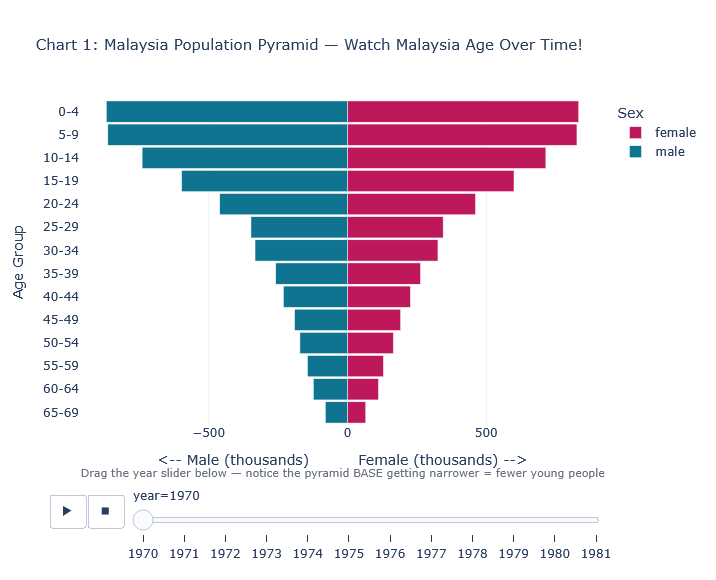


Successfully -> Saved: outputs/chart01_population_pyramid.html
INSIGHT: The pyramid base (young people) is getting narrower over time!
This means fewer births and an ageing population structure.


In [3]:

# ============================================================
# CHART: Population Pyramid
# ============================================================

pyramid = pop_malaysia[
    (pop_malaysia['ethnicity'] == 'overall') &
    (pop_malaysia['sex'].isin(['male', 'female'])) &
    (~pop_malaysia['age'].isin(['overall', '70+']))
].copy()

age_order = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34',
             '35-39','40-44','45-49','50-54','55-59','60-64',
             '65-69','70-74','75-79','80+']
age_order = [a for a in age_order if a in pyramid['age'].unique()]
pyramid   = pyramid[pyramid['age'].isin(age_order)].copy()

# Male = negative (left side)
pyramid['pop_plot'] = pyramid.apply(
    lambda r: -r['population'] if r['sex'] == 'male' else r['population'], axis=1
)
pyramid['age'] = pd.Categorical(pyramid['age'], categories=age_order, ordered=True)
pyramid = pyramid.sort_values(['year', 'age'])

print('Years available:', sorted(pyramid['year'].unique()))
print('Age groups     :', age_order)

fig = px.bar(
    pyramid,
    x='pop_plot',
    y='age',
    color='sex',
    animation_frame='year',
    orientation='h',
    color_discrete_map={'male': '#0E7490', 'female': '#BE185D'},
    title='Chart 1: Malaysia Population Pyramid — Watch Malaysia Age Over Time!',
    labels={'pop_plot': 'Population (thousands)', 'age': 'Age Group'},
    template='plotly_white',
    height=580,
    category_orders={'age': age_order}
)
fig.update_layout(
    title_font_size=15,
    bargap=0.08,
    xaxis_title='<-- Male (thousands)          Female (thousands) -->',
    legend_title='Sex',
    annotations=[dict(
        text='Drag the year slider below — notice the pyramid BASE getting narrower = fewer young people',
        showarrow=False, xref='paper', yref='paper',
        x=0.5, y=-0.18, font_size=11, font_color='#6B7280', xanchor='center'
    )]
)

fig.write_html('../outputs/chart01_population_pyramid.html')
fig.show()
print('\nSuccessfully -> Saved: outputs/chart01_population_pyramid.html')
print('INSIGHT: The pyramid base (young people) is getting narrower over time!')
print('This means fewer births and an ageing population structure.')

TFR rows: 66 | Years: 1958 - 2023
Latest TFR: 1.73 ( 2023 )


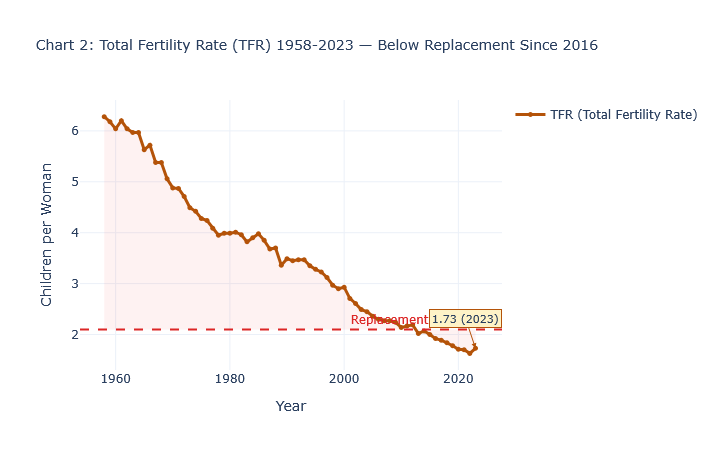


Successfully Saved: outputs/chart02_fertility_rate.html
INSIGHT: TFR = 1.73 -- below 2.1 replacement level!
Malaysia needs 2.1 children per woman to maintain population size. We have less.


In [4]:
# ============================================================
# CHART: Fertility Rate Trend (TFR)
# ============================================================

tfr = fertility[fertility['age_group'] == 'tfr'].sort_values('year').copy()
print('TFR rows:', len(tfr), '| Years:', tfr['year'].min(), '-', tfr['year'].max())
print('Latest TFR:', round(tfr.iloc[-1]['fertility_rate'], 2), '(', int(tfr.iloc[-1]['year']), ')')

fig = go.Figure()

# Shaded gap area between TFR and 2.1
fig.add_trace(go.Scatter(
    x=list(tfr['year']) + list(tfr['year'])[::-1],
    y=list(tfr['fertility_rate']) + [2.1] * len(tfr),
    fill='toself', fillcolor='rgba(239,68,68,0.07)',
    line=dict(color='rgba(0,0,0,0)'),
    showlegend=False, hoverinfo='skip'
))

# Main TFR line
fig.add_trace(go.Scatter(
    x=tfr['year'], y=tfr['fertility_rate'],
    mode='lines+markers',
    line=dict(color='#B45309', width=3),
    marker=dict(size=5),
    name='TFR (Total Fertility Rate)',
    hovertemplate='%{x}: %{y:.2f} children per woman'
))

# Replacement level
fig.add_hline(
    y=2.1, line_dash='dash', line_color='#DC2626', line_width=2,
    annotation_text='Replacement Level (2.1)',
    annotation_position='top right',
    annotation_font_color='#DC2626'
)

# Annotate latest
latest = tfr.iloc[-1]
fig.add_annotation(
    x=latest['year'], y=latest['fertility_rate'],
    text=str(round(latest['fertility_rate'], 2)) + ' (' + str(int(latest['year'])) + ')',
    showarrow=True, arrowhead=2, arrowcolor='#B45309',
    bgcolor='#FEF3C7', bordercolor='#B45309', font_size=11
)

fig.update_layout(
    title='Chart 2: Total Fertility Rate (TFR) 1958-2023 — Below Replacement Since 2016',
    xaxis_title='Year',
    yaxis_title='Children per Woman',
    template='plotly_white', height=450, title_font_size=14
)

fig.write_html('../outputs/chart02_fertility_rate.html')
fig.show()
print('\nSuccessfully Saved: outputs/chart02_fertility_rate.html')
print('INSIGHT: TFR =', round(latest['fertility_rate'],2), '-- below 2.1 replacement level!')
print('Malaysia needs 2.1 children per woman to maintain population size. We have less.')

Births rows   : 24 | years: 2000 - 2023
Deaths rows   : 24 | years: 2000 - 2023
Marriages rows: 6 | years: 2017 - 2022


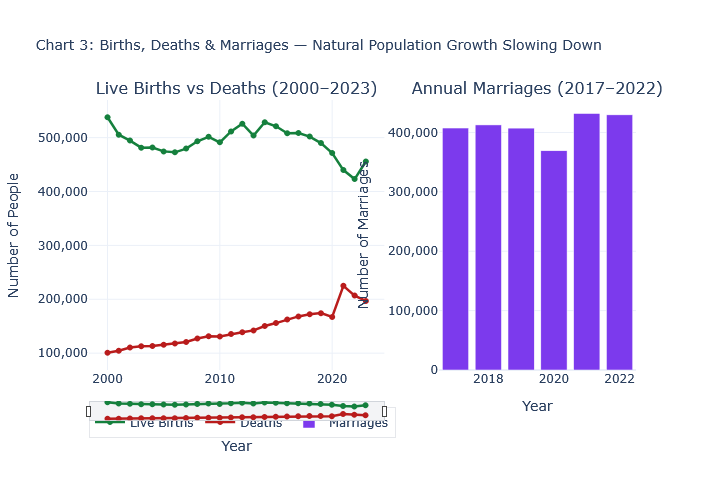


Successfully Saved: outputs/chart03_births_deaths_marriages.html
INSIGHT: Fewer marriages = fewer births = ageing population accelerates!


In [10]:
# ============================================================
# CHART: Births, Deaths & Marriages (WITH SLIDER)
# ============================================================

b = births.sort_values('year')
d = deaths.sort_values('year')

# Fix marriages filter
if 'sex' in marriages.columns:
    sex_vals = marriages['sex'].unique()
    if 'both' in sex_vals:
        m = marriages[marriages['sex'] == 'both'].sort_values('year')
    elif 'male' in sex_vals:
        m = marriages.groupby('year')['abs'].sum().reset_index()
    else:
        m = marriages.sort_values('year')
else:
    m = marriages.sort_values('year')

print('Births rows   :', len(b), '| years:', b['year'].min(), '-', b['year'].max())
print('Deaths rows   :', len(d), '| years:', d['year'].min(), '-', d['year'].max())
print('Marriages rows:', len(m), '| years:', m['year'].min(), '-', m['year'].max())

# ── Build figure with TWO subplots + range slider ────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Live Births vs Deaths (2000–2023)',
        'Annual Marriages (2017–2022)'
    ],
    column_widths=[0.60, 0.40],
    horizontal_spacing=0.10
)

# ── LEFT PANEL: Births line ───────────────────────────────────
fig.add_trace(go.Scatter(
    x=b['year'], y=b['abs'],
    mode='lines+markers',
    name='Live Births',
    line=dict(color='#15803D', width=2.5),
    marker=dict(size=6),
    hovertemplate='Year %{x}<br>Births: <b>%{y:,.0f}</b>'
), row=1, col=1)

# ── LEFT PANEL: Deaths line ───────────────────────────────────
fig.add_trace(go.Scatter(
    x=d['year'], y=d['abs'],
    mode='lines+markers',
    name='Deaths',
    line=dict(color='#B91C1C', width=2.5),
    marker=dict(size=6),
    hovertemplate='Year %{x}<br>Deaths: <b>%{y:,.0f}</b>'
), row=1, col=1)

# ── RIGHT PANEL: Marriages bar ────────────────────────────────
fig.add_trace(go.Bar(
    x=m['year'], y=m['abs'],
    name='Marriages',
    marker_color='#7C3AED',
    hovertemplate='Year %{x}<br>Marriages: <b>%{y:,.0f}</b>'
), row=1, col=2)

# ── Range slider (X axis only on left panel) ──────────────────
fig.update_xaxes(
    rangeslider=dict(
        visible=True,
        thickness=0.06,
        bgcolor='#F3F4F6',
        bordercolor='#D1D5DB',
        borderwidth=1
    ),
    rangeselector=dict(
        buttons=[
            dict(count=5,  label='5yr',  step='year', stepmode='backward'),
            dict(count=10, label='10yr', step='year', stepmode='backward'),
            dict(count=15, label='15yr', step='year', stepmode='backward'),
            dict(label='All',            step='all')
        ],
        bgcolor='#F9FAFB',
        activecolor='#15803D',
        font=dict(size=11)
    ),
    row=1, col=1
)

# ── Styling ───────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='Chart 3: Births, Deaths & Marriages — Natural Population Growth Slowing Down',
        font=dict(size=14)
    ),
    template='plotly_white',
    height=500,
    legend=dict(
        orientation='h',
        x=0.0, y=-0.25,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='#E5E7EB',
        borderwidth=1
    ),
    margin=dict(b=80)
)

fig.update_yaxes(tickformat=',', title_text='Number of People', row=1, col=1)
fig.update_yaxes(tickformat=',', title_text='Number of Marriages', row=1, col=2)
fig.update_xaxes(title_text='Year', row=1, col=1)
fig.update_xaxes(title_text='Year', row=1, col=2)

fig.write_html('../outputs/chart03_births_deaths_marriages.html')
fig.show()
print('\nSuccessfully Saved: outputs/chart03_births_deaths_marriages.html')
print('INSIGHT: Fewer marriages = fewer births = ageing population accelerates!')

Years available: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


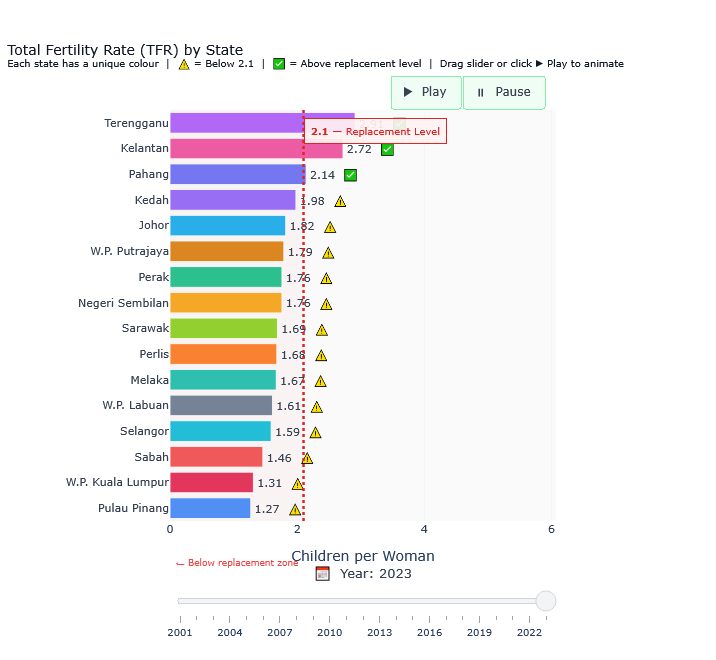


Successfully Saved: outputs/chart04_fertility_by_state.html

Latest year ( 2023 ) —
  States BELOW 2.1: ['Pulau Pinang', 'W.P. Kuala Lumpur', 'Sabah', 'Selangor', 'W.P. Labuan', 'Melaka', 'Perlis', 'Sarawak', 'Negeri Sembilan', 'Perak', 'W.P. Putrajaya', 'Johor', 'Kedah']
  States ABOVE 2.1: ['Pahang', 'Kelantan', 'Terengganu']

INSIGHT: Urban states like KL, Selangor, Penang have lowest TFR.
Higher cost of living = people delay or avoid having children.


In [19]:
# ============================================================
# CHART: Fertility Rate by State
# ============================================================

tfr_state = fertility_state[fertility_state['age_group'] == 'tfr'].copy()

state_colors = {
    'Johor'            : '#0EA5E9',
    'Kedah'            : '#8B5CF6',
    'Kelantan'         : '#EC4899',
    'Melaka'           : '#14B8A6',
    'Negeri Sembilan'  : '#F59E0B',
    'Pahang'           : '#6366F1',
    'Perak'            : '#10B981',
    'Perlis'           : '#F97316',
    'Pulau Pinang'     : '#3B82F6',
    'Sabah'            : '#EF4444',
    'Sarawak'          : '#84CC16',
    'Selangor'         : '#06B6D4',
    'Terengganu'       : '#A855F7',
    'W.P. Kuala Lumpur': '#E11D48',
    'W.P. Labuan'      : '#64748B',
    'W.P. Putrajaya'   : '#D97706',
}

all_years = sorted(tfr_state['year'].unique())
print('Years available:', all_years)

frames = []
for yr in all_years:
    df_yr = tfr_state[tfr_state['year'] == yr].sort_values('fertility_rate', ascending=True).copy()
    df_yr['label'] = df_yr['fertility_rate'].apply(
        lambda v: str(round(v, 2)) + '  ⚠️' if v < 2.1 else str(round(v, 2)) + '  ✅'
    )
    bar_colors = [state_colors.get(s, '#94A3B8') for s in df_yr['state']]
    frames.append(go.Frame(
        data=[go.Bar(
            x=df_yr['fertility_rate'],
            y=df_yr['state'],
            orientation='h',
            marker=dict(color=bar_colors, line=dict(color='white', width=0.8), opacity=0.88),
            text=df_yr['label'],
            textposition='outside',
            textfont=dict(size=11, color='#374151'),
            hovertemplate='<b>%{y}</b><br>TFR: %{x:.2f} children per woman<extra></extra>',
        )],
        name=str(yr)
    ))

latest_yr    = all_years[-1]
start_df     = tfr_state[tfr_state['year'] == latest_yr].sort_values('fertility_rate', ascending=True).copy()
max_tfr      = tfr_state['fertility_rate'].max()
start_df['label'] = start_df['fertility_rate'].apply(
    lambda v: str(round(v, 2)) + '  ⚠️' if v < 2.1 else str(round(v, 2)) + '  ✅'
)
start_colors = [state_colors.get(s, '#94A3B8') for s in start_df['state']]

fig = go.Figure(
    data=[go.Bar(
        x=start_df['fertility_rate'],
        y=start_df['state'],
        orientation='h',
        marker=dict(color=start_colors, line=dict(color='white', width=0.8), opacity=0.88),
        text=start_df['label'],
        textposition='outside',
        textfont=dict(size=11, color='#374151'),
        hovertemplate='<b>%{y}</b><br>TFR: %{x:.2f} children per woman<extra></extra>',
    )],
    frames=frames
)

steps = []
for yr in all_years:
    steps.append(dict(
        method='animate',
        label=str(yr),
        args=[
            [str(yr)],
            dict(mode='immediate',
                 frame=dict(duration=400, redraw=True),
                 transition=dict(duration=200))
        ]
    ))

sliders = [dict(
    active=len(all_years) - 1,
    currentvalue=dict(
        prefix='📅  Year: ',
        font=dict(size=13, color='#374151'),
        visible=True,
        xanchor='center'
    ),
    pad=dict(t=40, b=10),
    len=1.0,
    x=0.0,
    y=0.0,                          
    steps=steps,
    bgcolor='#F3F4F6',
    bordercolor='#D1D5DB',
    tickcolor='#9CA3AF',
    font=dict(size=10)
)]

updatemenus = [dict(
    type='buttons',
    showactive=False,
    direction='right',              
    x=0.99,                         
    xanchor='right',
    y=1.10,                        
    yanchor='top',
    buttons=[
        dict(
            label='▶  Play',
            method='animate',
            args=[
                None,
                dict(frame=dict(duration=700, redraw=True),
                     fromcurrent=True,
                     transition=dict(duration=300))
            ]
        ),
        dict(
            label='⏸  Pause',
            method='animate',
            args=[
                [None],
                dict(frame=dict(duration=0, redraw=False),
                     mode='immediate',
                     transition=dict(duration=0))
            ]
        )
    ],
    font=dict(size=12, color='#374151'),
    bgcolor='#F0FDF4',
    bordercolor='#86EFAC',
    borderwidth=1,
    pad=dict(r=8, t=6, b=6, l=8)
)]

fig.add_vline(
    x=2.1,
    line_dash='dot',
    line_color='#DC2626',
    line_width=2.5,
    annotation=dict(
        text='<b>2.1</b> — Replacement Level',
        font=dict(size=10, color='#DC2626'),
        bgcolor='rgba(254,242,242,0.92)',
        bordercolor='#DC2626',
        borderwidth=1,
        borderpad=5,
        yanchor='top',
        y=0.98
    ),
    annotation_position='top right'
)

fig.add_vrect(
    x0=0, x1=2.1,
    fillcolor='rgba(239,68,68,0.04)',
    layer='below', line_width=0
)

fig.add_annotation(
    x=1.05, y=-0.12,
    xref='x', yref='paper',
    text='← Below replacement zone',
    showarrow=False,
    font=dict(size=9, color='#EF4444'),
    xanchor='center'
)

fig.update_layout(
    title=dict(
        text=(
            'Total Fertility Rate (TFR) by State<br>'
            '<sup>Each state has a unique colour  |  '
            '⚠️ = Below 2.1  |  ✅ = Above replacement level  |  '
            'Drag slider or click ▶ Play to animate</sup>'
        ),
        font=dict(size=14, color='#111827'),
        x=0.01
    ),
    xaxis=dict(
        title='Children per Woman',
        range=[0, max_tfr + 1.2],
        showgrid=True,
        gridcolor='#F3F4F6',
        gridwidth=1,
        zeroline=False,
        tickfont=dict(size=11),
        fixedrange=True
    ),
    yaxis=dict(
        tickfont=dict(size=11, color='#374151'),
        showgrid=False,
        fixedrange=True
    ),
    template='plotly_white',
    height=660,
    margin=dict(l=170, r=160, t=110, b=120),
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white',
    showlegend=False,
    sliders=sliders,
    updatemenus=updatemenus
)

fig.write_html('../outputs/chart04_fertility_by_state.html')
fig.show()

below = start_df[start_df['fertility_rate'] < 2.1]['state'].tolist()
above = start_df[start_df['fertility_rate'] >= 2.1]['state'].tolist()

print('\nSuccessfully Saved: outputs/chart04_fertility_by_state.html')
print()
print('Latest year (', latest_yr, ') —')
print('  States BELOW 2.1:', below)
print('  States ABOVE 2.1:', above)
print()
print('INSIGHT: Urban states like KL, Selangor, Penang have lowest TFR.')
print('Higher cost of living = people delay or avoid having children.')

Ageing Index calculation:
  1970: young=4,847k | elderly=380k | index=7.8
  1971: young=4,907k | elderly=391k | index=8.0
  1972: young=4,975k | elderly=402k | index=8.1
  1973: young=5,038k | elderly=413k | index=8.2
  1974: young=5,100k | elderly=424k | index=8.3
  1975: young=5,170k | elderly=436k | index=8.4
  1976: young=5,229k | elderly=443k | index=8.5
  1977: young=5,302k | elderly=451k | index=8.5
  1978: young=5,365k | elderly=459k | index=8.6
  1979: young=5,436k | elderly=468k | index=8.6
  1980: young=5,542k | elderly=760k | index=13.7
  1981: young=5,622k | elderly=784k | index=14.0


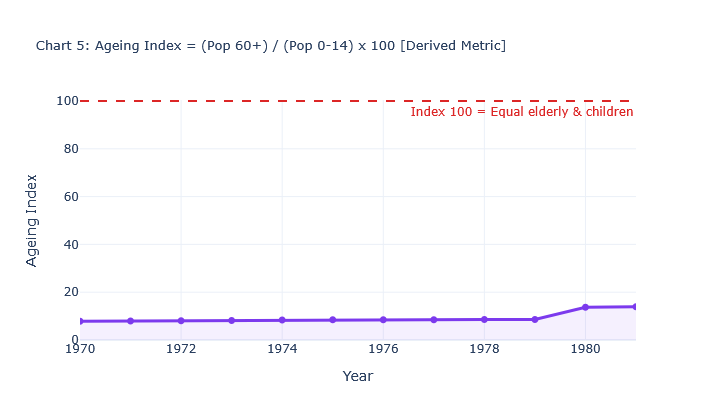


✅ Saved: outputs/chart05_ageing_index.html
INSIGHT: Ageing Index ( 1981 ) = 14.0


In [20]:
# ============================================================
# CHART: Ageing Index (Derived Metric)
# Ageing Index = Population 60+ / Population 0-14 x 100
# Index > 100 = more elderly than children = aged nation
# ============================================================

pop_mx = pop_malaysia[
    (pop_malaysia['sex'] == 'both') &
    (pop_malaysia['ethnicity'] == 'overall') &
    (pop_malaysia['age'] != 'overall')
].copy()

young_ages   = ['0-4', '5-9', '10-14']
elderly_ages = ['60-64', '65-69', '70-74', '75-79', '80+']

young   = pop_mx[pop_mx['age'].isin(young_ages)].groupby('year')['population'].sum().reset_index()
elderly = pop_mx[pop_mx['age'].isin(elderly_ages)].groupby('year')['population'].sum().reset_index()

ageing = pd.merge(young, elderly, on='year', suffixes=('_young', '_elderly'))
ageing['ageing_index'] = (ageing['population_elderly'] / ageing['population_young']) * 100

print('Ageing Index calculation:')
for _, row in ageing.iterrows():
    print(f'  {int(row["year"])}: young={row["population_young"]:,.0f}k | elderly={row["population_elderly"]:,.0f}k | index={row["ageing_index"]:.1f}')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ageing['year'], y=ageing['ageing_index'],
    mode='lines+markers',
    line=dict(color='#7C3AED', width=3),
    marker=dict(size=7),
    fill='tozeroy', fillcolor='rgba(124,58,237,0.08)',
    name='Ageing Index',
    hovertemplate='%{x}: Ageing Index = %{y:.1f}'
))

fig.add_hline(
    y=100, line_dash='dash', line_color='#DC2626', line_width=2,
    annotation_text='Index 100 = Equal elderly & children',
    annotation_position='bottom right',
    annotation_font_color='#DC2626'
)

fig.update_layout(
    title='Chart 5: Ageing Index = (Pop 60+) / (Pop 0-14) x 100 [Derived Metric]',
    xaxis_title='Year', yaxis_title='Ageing Index',
    template='plotly_white', height=420, title_font_size=13
)

fig.write_html('../outputs/chart05_ageing_index.html')
fig.show()
latest_ai = ageing.iloc[-1]
print('\n✅ Saved: outputs/chart05_ageing_index.html')
print('INSIGHT: Ageing Index (', int(latest_ai['year']), ') =', round(latest_ai['ageing_index'], 1))
if latest_ai['ageing_index'] >= 100:
    print('More elderly than children! Malaysia is officially an ageing nation!')